# Transformation

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#  Generate non-normal data(exponential Distribution)
np.random.seed(0)
df = np.random.exponential(size=1000, scale=2)
df = pd.DataFrame(df,columns=['Values'])
df.head()

,Values
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


In [5]:
df.shape

(1000, 1)

<Axes: xlabel='Values', ylabel='Count'>

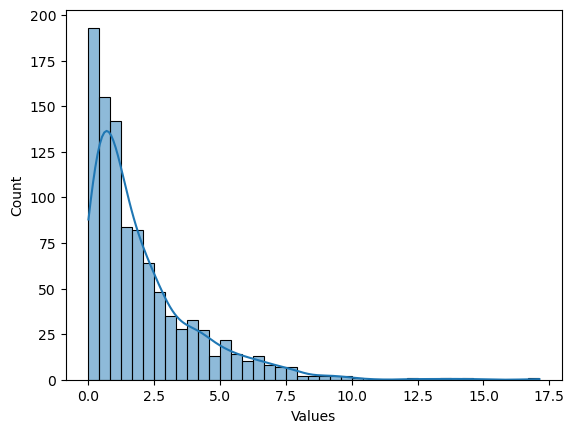

In [7]:
sns.histplot(df['Values'] , kde=True)

In [19]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer

pt_boxcox = PowerTransformer(method='box-cox')
pt_yeo_johnson = PowerTransformer(method='yeo-johnson')
qt_normal = QuantileTransformer(output_distribution='normal')

df['Box_Cox'] = pt_boxcox.fit_transform(df[['Values']] + 1 )
df['Yeo_Johnson'] = pt_yeo_johnson.fit_transform(df[['Values']])
df['Quantile'] = qt_normal.fit_transform(df[['Values']])

In [20]:
df.head()

,Values,Box_Cox,Yeo_Johnson,Quantile
0,1.591749,0.179335,0.179335,0.162552
1,2.511862,0.677330,0.677331,0.587964
2,1.846446,0.339698,0.339698,0.286135
3,1.574402,0.167607,0.167607,0.157469
4,1.102097,-0.202107,-0.202107,-0.154930


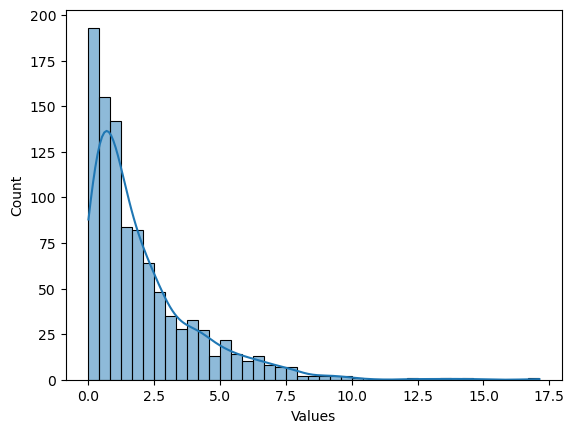

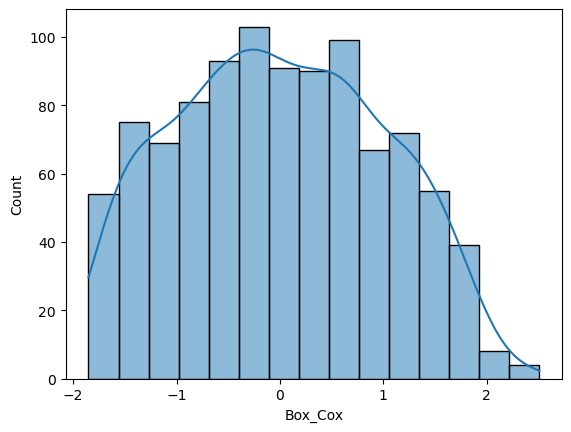

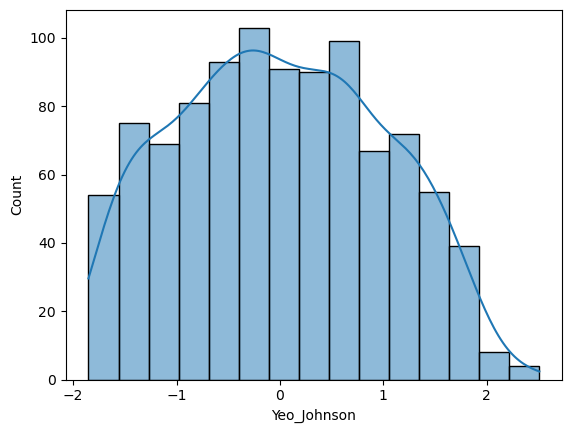

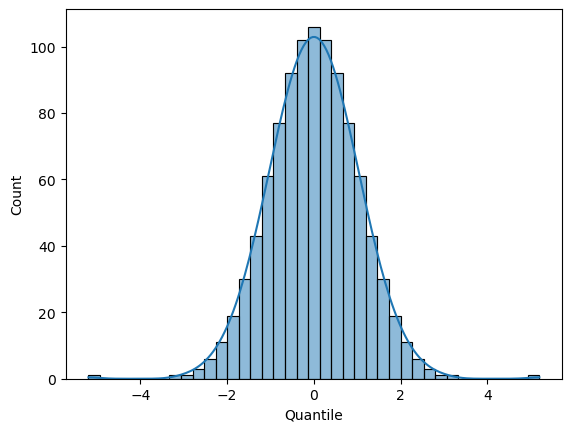

In [21]:
for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.show()

# Normalization

## L1 Normalization

In [24]:
from sklearn.preprocessing import Normalizer
data = [[1 ,1 ,1],[1, 1, 0],[1, 0, 0]]
normalizer = Normalizer(norm='l1')
print(normalizer.fit_transform(data))

[[0.33333333 0.33333333 0.33333333]
 [0.5        0.5        0.        ]
 [1.         0.         0.        ]]


## L2 Normalization

In [25]:
from sklearn.preprocessing import Normalizer
data = [[1 ,1 ,1],[1, 1, 0],[1, 0, 0]]
normalizer = Normalizer(norm='l2')
print(normalizer.fit_transform(data))

[[0.57735027 0.57735027 0.57735027]
 [0.70710678 0.70710678 0.        ]
 [1.         0.         0.        ]]


# log Normalization

In [29]:
df = {
    'values': [1,2,3,4,5,6,7,8,9,10,11,12, 43, 56, 23]
}
df = pd.DataFrame(df)
df.head()

,values
0,1
1,2
2,3
3,4
4,5


<Axes: xlabel='values', ylabel='Count'>

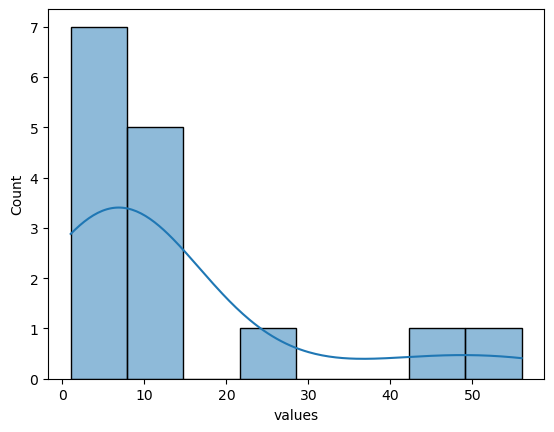

In [30]:
sns.histplot(df['values'], kde=True)

In [31]:
df['log_values'] = np.log(df['values'])
df.head()

,values,log_values
0,1,0.000000
1,2,0.693147
2,3,1.098612
3,4,1.386294
4,5,1.609438


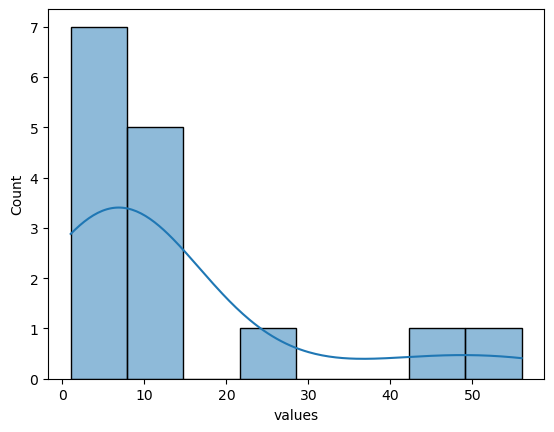

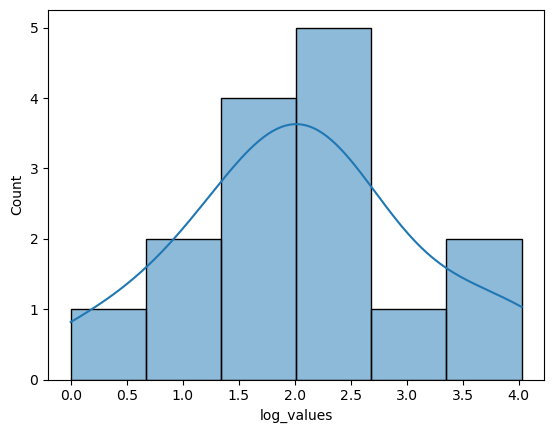

In [32]:
for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.show()